In [93]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
import torch
import sys
from scipy import stats

# Increase the font scale for seaborn
sns.set(font_scale=1.5)  # Adjust this value to increase or decrease font size
sns.set_style("white")  # Set the background to white

sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/simulation/')
from simulate_ALBF_calibration_eval import ALBFCalibrationAnalysis

In [94]:
# Main path set up
main_path="/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/Simulations/2025/manuscript_sim_analysis"

# Choose which simulation directory to analyze 
dir_analyze="analysis_20250122_152749_PropNeg_0.5_K_2_NoWaypoints_Prior_NoGlobalPrior_NumEpochs_100_LearnedConc_Inits_2_NoCellType_Random_76295"

# Set up the path to the simulation directory
sim_dir=os.path.join(main_path,dir_analyze)

# Print the names of the files in the simulation directory
files = os.listdir(sim_dir)
print(files)

['clustermap.png', 'losses.png', 'random_init_26611_loss_curve.png', 'assignment_correlations.png', 'est_deltapsi_vs_difference.png', 'pi_barplot.png', 'nmf_clustermap.png', 'nmf_umap.png.pdf', 'ALBF_scores.csv', 'albf_vs_difference.png', 'cell_type_psi_df.csv', 'final_results.csv', 'ALBF_report.txt', 'umap.png.pdf', 'roc_curve.png', 'est_deltapsi_vs_difference.pdf', 'parameters.json', 'precision_recall_curve.png', 'analysis_report.txt', 'precision_recall_curve.pdf', 'ALBF_score_distribution.png', 'random_init_43945_loss_curve.png']


In [95]:
# Original PSI_df from simulation
PSI_df = pd.read_csv(os.path.join(sim_dir, "cell_type_psi_df.csv"))

In [96]:
PSI_df[PSI_df["true_label"] == "negative"]

,index,0,1,junction_id_index,junction_id,sample_label,Cluster,difference,true_label
9,0,0.437822,0.437822,9,chr10_102350984_102370332_+,negative,35079,0.0,negative
10,1,0.124356,0.124356,10,chr10_102350984_102378151_+,negative,35079,0.0,negative
11,2,0.437822,0.437822,11,chr10_102370393_102378151_+,negative,35079,0.0,negative
12,0,0.441088,0.441088,12,chr10_106762147_106767473_+,negative,35976,0.0,negative
13,1,0.117823,0.117823,13,chr10_106762147_106800736_+,negative,35976,0.0,negative
...,...,...,...,...,...,...,...,...,...
15877,1,0.360291,0.360291,15877,chrY_1012169_1014633_+,negative,62099,0.0,negative
15878,2,0.319855,0.319855,15878,chrY_1013473_1014633_+,negative,62099,0.0,negative
15882,0,0.353195,0.353195,15882,chrY_1168185_1169122_-,negative,62114,0.0,negative
15883,1,0.293610,0.293610,15883,chrY_1168185_1169964_-,negative,62114,0.0,negative


In [97]:
PSI_df.sample_label.value_counts()

sample_label
positive    7947
negative    7947
Name: count, dtype: int64

In [98]:
# let's load the final_results.csv file 
albf_scores = pd.read_csv(os.path.join(sim_dir, "ALBF_scores.csv"))
# rename the first two columns to be sim_psi_1 and sim_psi_2
albf_scores = albf_scores.rename(columns={"0": "latent_psi_1", "1": "latent_psi_2"})
albf_scores.head()

,latent_psi_1,latent_psi_2,junction_id_index,ALBF,difference,true_label,Cluster,true_label_binary,delta_est,predicted_label
0,0.057541,0.382382,0,14.841497,0.309640,positive,35178,1,0.324841,1
1,0.879922,0.229320,1,21.884650,0.619281,positive,35178,1,0.650602,1
2,0.056158,0.386209,2,11.329762,0.309640,positive,35178,1,0.330051,1
3,0.340236,0.120571,3,4.177542,0.215535,positive,37286,1,0.219665,1
4,0.305849,0.754290,4,7.596017,0.431071,positive,37286,1,0.448441,1


In [99]:
albf_scores[albf_scores["true_label"] == "negative"].sort_values(by="ALBF", ascending=False)

,latent_psi_1,latent_psi_2,junction_id_index,ALBF,difference,true_label,Cluster,true_label_binary,delta_est,predicted_label
9033,0.000821,0.004119,9033,3.983185,0.0,negative,11699,0,0.003298,1
798,0.004192,0.001003,798,2.401306,0.0,negative,38241,0,0.003189,1
13247,0.000736,0.003383,13247,2.319275,0.0,negative,23169,0,0.002647,1
7096,0.992125,0.997901,7096,1.763550,0.0,negative,3243,0,0.005776,1
6799,0.489463,0.966346,6799,1.749799,0.0,negative,1867,0,0.476882,1
...,...,...,...,...,...,...,...,...,...,...
8092,0.222069,0.217016,8092,0.000004,0.0,negative,6236,0,0.005053,0
3048,0.458892,0.461796,3048,0.000002,0.0,negative,46713,0,0.002904,0
14742,0.076499,0.076162,14742,0.000000,0.0,negative,31175,0,0.000337,0
8348,0.051142,0.051876,8348,-0.000023,0.0,negative,4530,0,0.000735,0


In [100]:
def analyze_null_albf(df):
    """
    Analyze ALBF distribution for negative junctions
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing 'ALBF' and 'true_label' columns
    
    Returns
    -------
    dict
        Dictionary containing null distribution parameters
    """
    # Get ALBF values for negative junctions
    null_albf = df[df['true_label'] == 'negative']['ALBF']
    
    # Fit normal distribution to null ALBFs
    mu, std = stats.norm.fit(null_albf)
    
    # Test for normality
    _, norm_pval = stats.normaltest(null_albf)
    
    # Create visualization
    plt.figure(figsize=(10, 6))
    
    # Plot histogram of null ALBF values
    sns.histplot(null_albf, bins=30, color='blue', alpha=0.5, label='Observed')
    
    # Plot fitted normal distribution
    x = np.linspace(null_albf.min(), null_albf.max(), 100)
    plt.plot(x, stats.norm.pdf(x, mu, std) * len(null_albf) * (null_albf.max() - null_albf.min()) / 30,
             'r-', label='Fitted Normal')
    
    plt.title(f'Distribution of ALBF Values for Negative Junctions\nμ={mu:.2f}, σ={std:.2f}, p={norm_pval:.2e}')
    plt.xlabel('ALBF')
    plt.ylabel('Count')
    plt.legend()
    
    # Calculate percentiles for potential thresholds
    percentiles = [90, 95, 99]
    thresholds = np.percentile(null_albf, percentiles)
    
    return {
        'mu': mu,
        'std': std,
        'normality_pvalue': norm_pval,
        'thresholds': dict(zip(percentiles, thresholds))
    }

In [101]:
PSI_df[PSI_df["sample_label"] == "positive"]["difference"].min()

0.0003540516

<Axes: >

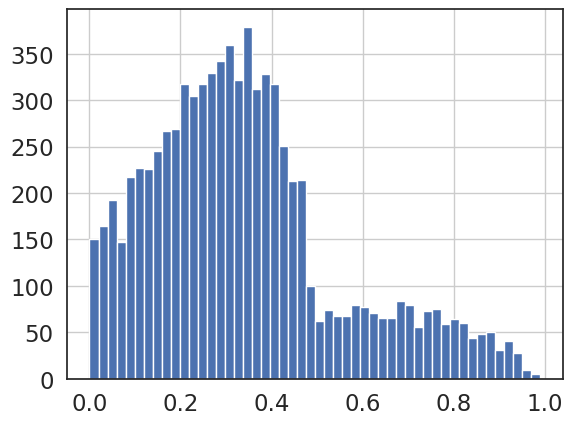

In [102]:
PSI_df[PSI_df["sample_label"] == "positive"]["difference"].hist(bins=50)

In [103]:
albf_scores.sort_values(by=["true_label", "ALBF"], ascending=[True, False], inplace=True)
albf_scores

,latent_psi_1,latent_psi_2,junction_id_index,ALBF,difference,true_label,Cluster,true_label_binary,delta_est,predicted_label
9033,0.000821,0.004119,9033,3.983185,0.000000,negative,11699,0,0.003298,1
798,0.004192,0.001003,798,2.401306,0.000000,negative,38241,0,0.003189,1
13247,0.000736,0.003383,13247,2.319275,0.000000,negative,23169,0,0.002647,1
7096,0.992125,0.997901,7096,1.763550,0.000000,negative,3243,0,0.005776,1
6799,0.489463,0.966346,6799,1.749799,0.000000,negative,1867,0,0.476882,1
...,...,...,...,...,...,...,...,...,...,...
3574,0.450464,0.445763,3574,0.000536,0.005372,positive,49257,1,0.004701,0
7663,0.313004,0.316283,7663,0.000374,0.007192,positive,7835,1,0.003279,0
12858,0.161538,0.163482,12858,0.000315,0.005479,positive,25851,1,0.001943,0
6812,0.390061,0.388580,6812,0.000158,0.025322,positive,3114,1,0.001481,0


In [104]:
# get range of ALBF scores
albf_scores["ALBF"].min(), albf_scores["ALBF"].max()

(-3.0517112e-05, 46.0517)

In [105]:
albf_scores[albf_scores["true_label"] == "negative"].sort_values(by="delta_est", ascending=False).head(100)

,latent_psi_1,latent_psi_2,junction_id_index,ALBF,difference,true_label,Cluster,true_label_binary,delta_est,predicted_label
6799,0.489463,0.966346,6799,1.749799,0.0,negative,1867,0,0.476882,1
5914,0.783691,0.369124,5914,0.722843,0.0,negative,58338,0,0.414567,1
6798,0.209096,0.020809,6798,0.791846,0.0,negative,1867,0,0.188287,1
13374,0.424501,0.242973,13374,0.363575,0.0,negative,27366,0,0.181528,1
6800,0.187368,0.020996,6800,0.712600,0.0,negative,1867,0,0.166372,1
...,...,...,...,...,...,...,...,...,...,...
10993,0.209139,0.250971,10993,0.132497,0.0,negative,18128,0,0.041832,0
7258,0.780284,0.821817,7258,0.037774,0.0,negative,1681,0,0.041533,0
8983,0.736502,0.695018,8983,0.048972,0.0,negative,10420,0,0.041484,0
13163,0.474439,0.432984,13163,0.034241,0.0,negative,27802,0,0.041454,0


In [106]:
PSI_df.iloc[177], PSI_df.iloc[178], PSI_df.iloc[179]

(index                                        0
 0                                     0.441585
 1                                     0.441585
 junction_id_index                          177
 junction_id          chr10_20332261_20332395_+
 sample_label                          negative
 Cluster                                  35770
 difference                                 0.0
 true_label                            negative
 Name: 177, dtype: object,
 index                                        1
 0                                      0.11683
 1                                      0.11683
 junction_id_index                          178
 junction_id          chr10_20332261_20333391_+
 sample_label                          negative
 Cluster                                  35770
 difference                                 0.0
 true_label                            negative
 Name: 178, dtype: object,
 index                                        2
 0                                

In [107]:
albf_scores[albf_scores["Cluster"] == 35770]

,latent_psi_1,latent_psi_2,junction_id_index,ALBF,difference,true_label,Cluster,true_label_binary,delta_est,predicted_label
177,0.441256,0.455904,177,0.014071,0.0,negative,35770,0,0.014649,0
179,0.432167,0.439543,179,0.013364,0.0,negative,35770,0,0.007377,0
178,0.115111,0.116520,178,0.000244,0.0,negative,35770,0,0.001409,0


{'mu': 0.030320547075171286,
 'std': 0.10981615972460074,
 'normality_pvalue': 0.0,
 'thresholds': {90: 0.05473824700000001,
  95: 0.10855902749999995,
  99: 0.41542450119999996}}

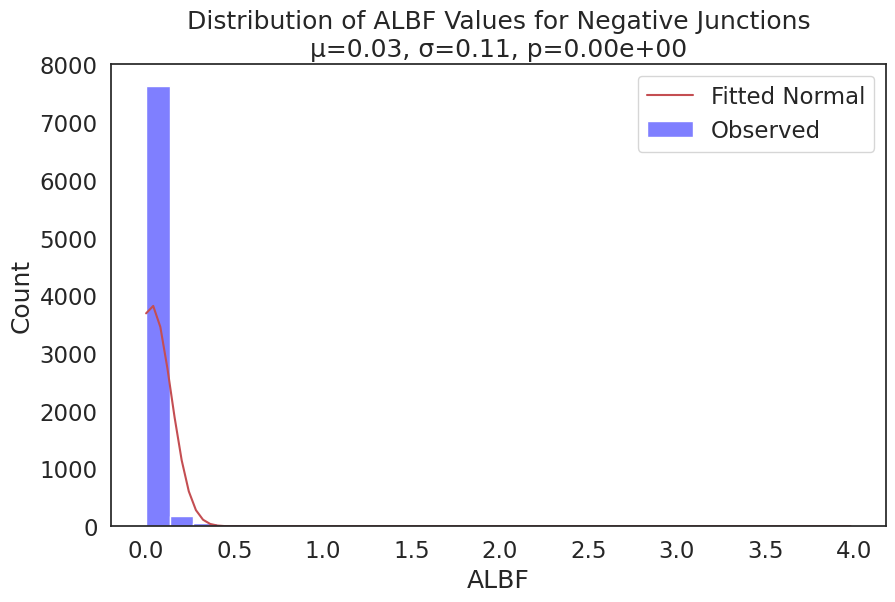

In [108]:
analyze_null_albf(albf_scores)

In [109]:
albf_scores[(albf_scores["true_label"] == "positive") & (albf_scores["ALBF"] > 2)].shape

(6262, 10)

In [110]:
# how many negative junctions have values greater than 10 ALBF?
albf_scores[(albf_scores["true_label"] == "negative") & (albf_scores["ALBF"] > 2)].shape

(3, 10)

<Axes: xlabel='ALBF', ylabel='Count'>

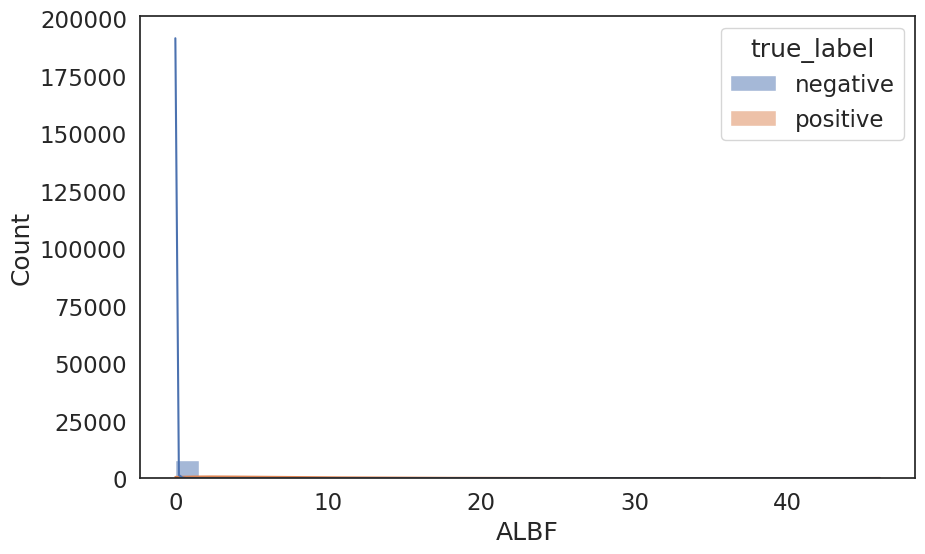

In [111]:
# Plot ALBF values distribtion for negative and positive junctions 
plt.figure(figsize=(10, 6))

# plot distplot 
sns.histplot(data=albf_scores, x='ALBF', hue='true_label', bins=30, kde=True, alpha=0.5)

<Axes: xlabel='difference', ylabel='ALBF'>

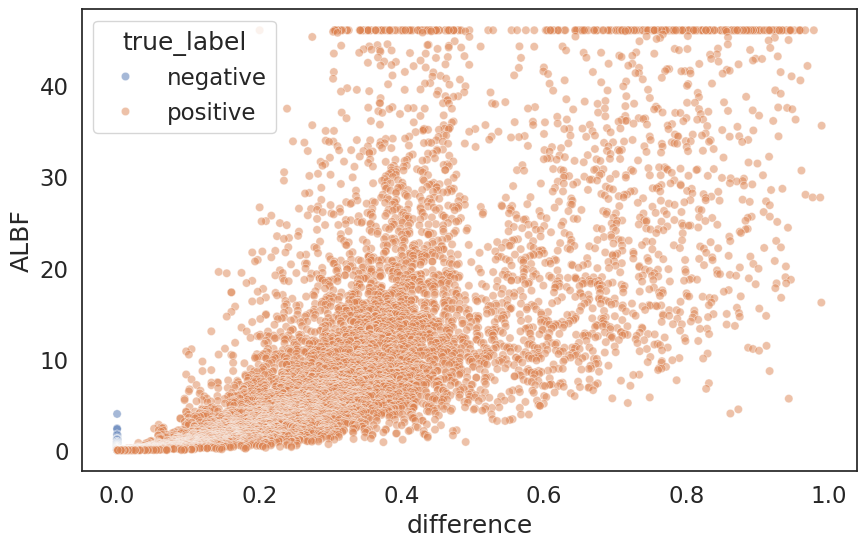

In [112]:
# let's plot difference column vs ALBF column for positive junctions under true_label
plt.figure(figsize=(10, 6))
sns.scatterplot(albf_scores, x='difference', y='ALBF', alpha=0.5, hue='true_label')

<Axes: >

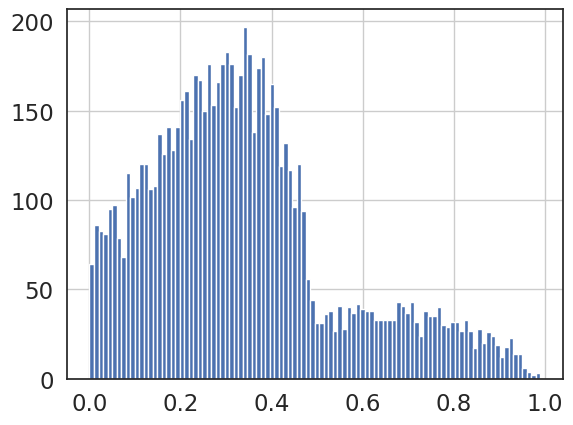

In [113]:
albf_scores[albf_scores["true_label"] == "positive"].difference.hist(bins=100)

<Axes: >

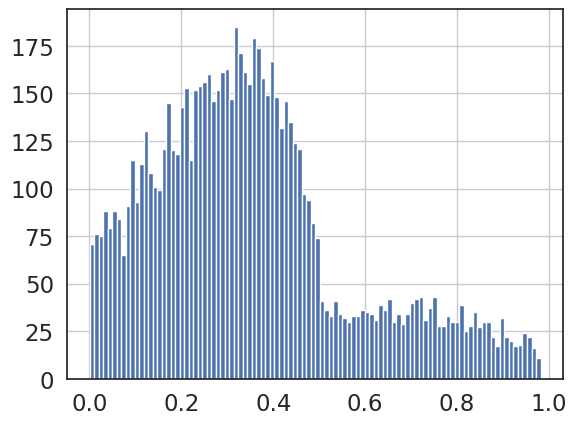

In [114]:
albf_scores[albf_scores["true_label"] == "positive"].delta_est.hist(bins=100)

In [115]:
PSI_df

,index,0,1,junction_id_index,junction_id,sample_label,Cluster,difference,true_label
0,0,0.064405,0.374046,0,chr10_100080130_100080856_+,positive,35178,0.309640,positive
1,1,0.871189,0.251908,1,chr10_100080130_100087346_+,positive,35178,0.619281,positive
2,2,0.064405,0.374046,2,chr10_100080940_100087346_+,positive,35178,0.309640,positive
3,0,0.341569,0.126034,3,chr10_100478022_100485050_-,positive,37286,0.215535,positive
4,1,0.316861,0.747932,4,chr10_100478022_100487161_-,positive,37286,0.431071,positive
...,...,...,...,...,...,...,...,...,...
15889,1,0.129055,0.837247,15889,chrY_898115_899427_+,positive,62094,0.708191,positive
15890,2,0.435472,0.081377,15890,chrY_898627_899427_+,positive,62094,0.354096,positive
15891,0,0.472301,0.090640,15891,chrY_900613_910447_+,positive,62095,0.381661,positive
15892,1,0.055398,0.818720,15892,chrY_910586_910656_+,positive,62095,0.763322,positive
